# 05 – Feature Engineering: Variables Demográficas

**Proyecto:** Encuesta Permanente de Empleo Nacional (EPEN)  
**Objetivo:** Construir variables derivadas de características demográficas (edad, sexo, estado civil) para enriquecer el perfil del individuo y mejorar la predicción.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

FE_DIR = os.path.join('..', 'data', 'feature_engineering')
try:
    df = pd.read_csv(os.path.join(FE_DIR, 'epen_fe_education.csv'))
except FileNotFoundError:
    np.random.seed(42)
    n = 1000
    df = pd.DataFrame({
        'edad': np.random.randint(14, 70, n),
        'sexo_bin': np.random.randint(0, 2, n),
        'nivel_educativo_ord': np.random.randint(0, 6, n),
        'target_desocupado': np.random.choice([0, 1], n, p=[0.50, 0.50]),
    })

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

Dataset cargado: 1,000 filas × 4 columnas


## 1. Grupo etario

In [9]:
if 'edad' in df.columns:
    bins = [13, 17, 24, 34, 44, 54, 64, 120]
    labels = [0, 1, 2, 3, 4, 5, 6]  # 14-17, 18-24, 25-34, 35-44, 45-54, 55-64, 65+
    df['grupo_etario'] = pd.cut(df['edad'], bins=bins, labels=labels).astype(int)
    print('Variable creada: grupo_etario')
    etario_labels = {0:'14-17', 1:'18-24', 2:'25-34', 3:'35-44', 4:'45-54', 5:'55-64', 6:'65+'}
    print(df['grupo_etario'].map(etario_labels).value_counts().sort_index())

Variable creada: grupo_etario
grupo_etario
14-17     73
18-24    113
25-34    164
35-44    189
45-54    197
55-64    170
65+       94
Name: count, dtype: int64


## 2. Indicador de juventud (14–24 años)

Los jóvenes presentan tasas de desocupación significativamente más altas.

In [10]:
if 'edad' in df.columns:
    df['es_joven'] = ((df['edad'] >= 14) & (df['edad'] <= 24)).astype(int)
    print('Variable creada: es_joven')
    print(df['es_joven'].value_counts())

Variable creada: es_joven
es_joven
0    814
1    186
Name: count, dtype: int64


## 3. Indicador de adulto mayor en edad laboral (55–64 años)

In [11]:
if 'edad' in df.columns:
    df['adulto_mayor_activo'] = ((df['edad'] >= 55) & (df['edad'] <= 64)).astype(int)
    print('Variable creada: adulto_mayor_activo')
    print(df['adulto_mayor_activo'].value_counts())

Variable creada: adulto_mayor_activo
adulto_mayor_activo
0    830
1    170
Name: count, dtype: int64


## 4. Interacción sexo × educación superior

In [12]:
if 'sexo_bin' in df.columns and 'educacion_superior' in df.columns:
    df['mujer_con_edu_superior'] = ((df['sexo_bin'] == 0) & (df['educacion_superior'] == 1)).astype(int)
    print('Variable creada: mujer_con_edu_superior')
    print(df['mujer_con_edu_superior'].value_counts())
elif 'nivel_educativo_ord' in df.columns and 'sexo_bin' in df.columns:
    df['educacion_superior'] = (df['nivel_educativo_ord'] >= 4).astype(int)
    df['mujer_con_edu_superior'] = ((df['sexo_bin'] == 0) & (df['educacion_superior'] == 1)).astype(int)
    print('Variable creada: mujer_con_edu_superior')
    print(df['mujer_con_edu_superior'].value_counts())

Variable creada: mujer_con_edu_superior
mujer_con_edu_superior
0    824
1    176
Name: count, dtype: int64


## 5. Visualización: Tasa de desocupación por grupo etario

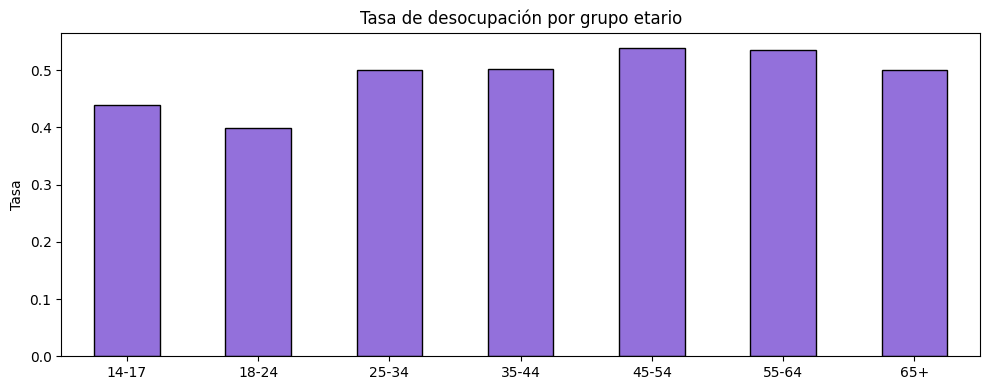

In [13]:
if 'grupo_etario' in df.columns and 'target_desocupado' in df.columns:
    etario_labels = {0:'14-17', 1:'18-24', 2:'25-34', 3:'35-44', 4:'45-54', 5:'55-64', 6:'65+'}
    tasa = df.groupby('grupo_etario')['target_desocupado'].mean()
    tasa.index = tasa.index.map(etario_labels)
    tasa.plot(kind='bar', color='mediumpurple', edgecolor='black', figsize=(10, 4))
    plt.title('Tasa de desocupación por grupo etario')
    plt.ylabel('Tasa')
    plt.xlabel('')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [14]:
os.makedirs(FE_DIR, exist_ok=True)
df.to_csv(os.path.join(FE_DIR, 'epen_fe_demographic.csv'), index=False)
nuevas = ['grupo_etario', 'es_joven', 'adulto_mayor_activo', 'mujer_con_edu_superior']
print('Nuevas variables demográficas:', [c for c in nuevas if c in df.columns])
print('Dataset guardado: epen_fe_demographic.csv')

Nuevas variables demográficas: ['grupo_etario', 'es_joven', 'adulto_mayor_activo', 'mujer_con_edu_superior']
Dataset guardado: epen_fe_demographic.csv
